# 06 - HEMT-CLIP Demo

Interactive demo of the headline **HEMT-CLIP** - the alpha-gated cross-attention model (`gated_fusion`), the best detector in our ablation (test F1 0.839 / AUC 0.912; notebook 04).

Given a post (**title + image**), the model predicts **REAL vs FAKE** with a confidence score and explains *that same multimodal decision* two ways:
- a **cross-attention heatmap** - where on the image the model looked;
- a **highlighted headline** - which words pushed the verdict (SHAP + LIME on the multimodal model, image held fixed).

**What "FAKE" means here.** This is the Fakeddit *2-way* label, not "this statement is a lie." It collapses Fakeddit's taxonomy - satire, manipulated images, misleading content, false text-image connection, imposter - into one **FAKE** class, with authentic posts as **REAL**. Labels come from the source subreddits, so we predict *the dataset's label*, not ground-truth veracity.

**Scope of this demo.** Every headline example below is a row from the **held-out Fakeddit test set** - the same data behind the 0.839 F1 - so each prediction is verified and reproducible. We show one out-of-distribution input at the end as a *documented limitation*, deliberately, not as a headline.

The `analyze(title, image)` helper runs the prediction and both explanations in one call.

## Setup
Prepares the environment and loads the dataset. Idempotent — safe to re-run. Warnings are silenced so the demo output stays clean.

In [ ]:
# Bootstrap — idempotent. Safe to re-run on a fresh or warm Colab runtime.
import os, sys, subprocess, shutil

# Env vars FIRST — must be set before any transformers import.
os.environ['USE_FLAX'] = 'FALSE'
os.environ['USE_TF'] = 'FALSE'
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = '1'

# Silence the deprecation/user warnings so the demo output stays clean.
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
REPO_URL = 'https://github.com/staharizvi/hemt-clip-fnd.git'
REPO_DIR = '/content/hemt-clip-fnd'
H5_DRIVE = '/content/drive/MyDrive/hemt-clip-fnd/data/fakeddit.h5'
H5_LOCAL = '/content/fakeddit.h5'

if IN_COLAB:
    if not os.path.ismount('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')
    else:
        print('Drive already mounted.')

    if os.path.exists(os.path.join(REPO_DIR, '.git')):
        print('Repo present \u2014 pulling latest\u2026')
        subprocess.run(['git', '-C', REPO_DIR, 'pull', '--quiet'], check=True)
    else:
        print('Cloning repo\u2026')
        subprocess.run(['git', 'clone', '--quiet', REPO_URL, REPO_DIR], check=True)

    subprocess.run(['pip', 'install', '-q', '-r', f'{REPO_DIR}/requirements.txt'], check=True)
    # jaxlib/jax/flax force numpy>=2 and clash with the project numpy pin.
    subprocess.run(['pip', 'uninstall', '-y', '-q', 'jax', 'jaxlib', 'flax'], check=False)

    if not os.path.exists(H5_LOCAL):
        if os.path.exists(H5_DRIVE):
            print(f'Copying {H5_DRIVE} -> {H5_LOCAL}\u2026')
            shutil.copy(H5_DRIVE, H5_LOCAL)
        else:
            print(f'WARNING: {H5_DRIVE} not found \u2014 run the data-prep notebook first.')
    else:
        print(f'h5 already at {H5_LOCAL}.')

    os.chdir(REPO_DIR)

print('\ncwd:', os.getcwd())
print('h5 :', H5_LOCAL, 'exists:', os.path.exists(H5_LOCAL))

Mounted at /content/drive
Cloning repo…
Copying /content/drive/MyDrive/hemt-clip-fnd/data/fakeddit.h5 -> /content/fakeddit.h5…

cwd: /content/hemt-clip-fnd
h5 : /content/fakeddit.h5 exists: True


## Dataset path
Point the demo at the local copy of the dataset.

In [ ]:
import yaml, pathlib
cfg_path = pathlib.Path('configs/base.yaml')
cfg = yaml.safe_load(cfg_path.read_text())
if cfg['data']['hdf5_path'] != '/content/fakeddit.h5':
    cfg['data']['hdf5_path'] = '/content/fakeddit.h5'
    cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
    print('Patched cfg.data.hdf5_path -> /content/fakeddit.h5')
else:
    print('cfg already points at local HDF5.')

Patched cfg.data.hdf5_path -> /content/fakeddit.h5


## Load the model
Load the headline **HEMT-CLIP** (`gated_fusion`) - used for the prediction, the attention heatmap, and (with the image held fixed) the text word-importance. CLIP is also loaded to compute the text-image similarity alpha. The checkpoint is auto-discovered.

In [ ]:
import yaml, torch
from pathlib import Path
from transformers import AutoTokenizer, CLIPModel, CLIPTokenizer
from models.hemt_clip import build_from_config
from training.evaluate import discover_checkpoints

VARIANT = 'gated_fusion'   # headline HEMT-CLIP: we predict with it AND explain it

with open('configs/base.yaml') as f:
    cfg = yaml.safe_load(f)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpts = discover_checkpoints(Path(cfg['checkpointing']['dir']))
if VARIANT not in ckpts:
    raise FileNotFoundError(f"No '{VARIANT}' checkpoint found. Train it in notebook 03 first.")
ckpt_path = ckpts[VARIANT]

model = build_from_config(cfg, variant=VARIANT).to(device).eval()
payload = torch.load(ckpt_path, map_location=device, weights_only=False)
state = payload['model'] if isinstance(payload, dict) and 'model' in payload else payload
model.load_state_dict(state, strict=True)

tokenizer = AutoTokenizer.from_pretrained(cfg['model']['text']['name'])
clip_model = CLIPModel.from_pretrained(cfg['model']['image']['name']).to(device).eval()
clip_tokenizer = CLIPTokenizer.from_pretrained(cfg['model']['image']['name'])
print('device         :', device.type)
print('HEMT-CLIP ckpt :', ckpt_path.name)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

device         : cuda
HEMT-CLIP ckpt : hemt_gated_fusion_20260531-2116_best.pt


## Inference + explainability helpers
One entry point: **`analyze(title, image)`**. It predicts (REAL/FAKE + confidence + alpha) and explains the *same multimodal model* two ways:
- a **cross-attention heatmap** - where on the image it looked;
- a **highlighted headline** - red = a word pushed the model toward FAKE, green = toward REAL (darker = stronger); the image contributes separately (that's the heatmap).

The word attributions are SHAP/LIME run on the multimodal model **with the image held fixed**, so they explain the actual verdict. Call **`analyze(title, image, bars=True)`** to also show the SHAP and LIME bar charts.

In [ ]:
import re
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from IPython.display import display, HTML
from data.dataset import CLIP_MEAN, CLIP_STD

MAX_LEN = cfg['data']['max_text_len']

# Function words carry no evidence; muted in the headline highlight and the
# plain-English summary so the explanation focuses on content words.
STOPWORDS = {'a', 'an', 'the', 'of', 'to', 'in', 'on', 'at', 'is', 'it', 'its',
             'was', 'were', 'be', 'by', 'for', 'and', 'or', 'as', 'this', 'that',
             'with', 'from', 'has', 'have', 'had', 'will', 'would', 'can', 'could',
             'i', 'you', 'he', 'she', 'they', 'we', 'his', 'her', 'their', 'our',
             'my', 'me', 'so', 'but', 'if', 'no', 'not', 'do', 'does', 'did'}

import shap
from lime.lime_text import LimeTextExplainer
_shap_masker = shap.maskers.Text(tokenizer)
_lime_explainer = LimeTextExplainer(class_names=['real', 'fake'])


def _clean_text(s):
    """Normalize text to Fakeddit's clean_title format the model trained on
    (lowercase, punctuation removed). Real capitalized/punctuated headlines are
    out-of-distribution for the fine-tuned text branch without this."""
    s = s.lower()
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


# ---- Image-side: preprocessing, prediction, attention ------------------------
def preprocess_image(pil_img):
    img = pil_img.convert('RGB').resize((224, 224), Image.BICUBIC)
    arr = (np.asarray(img, dtype=np.float32) / 255.0).transpose(2, 0, 1)
    return (arr - CLIP_MEAN[:, None, None]) / CLIP_STD[:, None, None]


@torch.no_grad()
def compute_alpha(pil_img, text):
    pixel_values = torch.from_numpy(preprocess_image(pil_img)).unsqueeze(0).to(device)
    enc = clip_tokenizer([text], padding='max_length', truncation=True,
                         max_length=77, return_tensors='pt').to(device)
    img_emb = F.normalize(clip_model.get_image_features(pixel_values=pixel_values).float(), dim=-1)
    txt_emb = F.normalize(clip_model.get_text_features(
        input_ids=enc['input_ids'], attention_mask=enc['attention_mask']).float(), dim=-1)
    return float((img_emb * txt_emb).sum(dim=-1).item())


@torch.no_grad()
def predict(pil_img, text, alpha):
    pixel_values = torch.from_numpy(preprocess_image(pil_img)).unsqueeze(0).to(device)
    enc = tokenizer([text], padding='max_length', truncation=True,
                    max_length=MAX_LEN, return_tensors='pt').to(device)
    batch = {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'],
             'pixel_values': pixel_values,
             'alpha': torch.tensor([alpha], dtype=torch.float32, device=device),
             'label': torch.tensor([0], dtype=torch.long, device=device)}
    out = model(batch)
    probs = torch.softmax(out['logits'].float(), dim=-1).cpu().numpy()[0]
    attn_grid = None
    if 'attention_weights' in out:
        a = out['attention_weights'].float().cpu().numpy()[0].mean(axis=0).squeeze(0)
        pn = int(round(np.sqrt(len(a))))
        attn_grid = a.reshape(pn, pn)
    return probs, attn_grid


def interpret_alpha(alpha):
    if alpha < 0.20:
        return f'low ({alpha:.3f}) - text and image weakly aligned'
    if alpha < 0.33:
        return f'typical ({alpha:.3f}) - usual band for Fakeddit pairs'
    return f'high ({alpha:.3f}) - strong text-image alignment'


def _attention_overlay(pil_img, attn_grid):
    img_arr = np.array(pil_img.convert('RGB').resize((224, 224)))
    t = torch.from_numpy(attn_grid).float().unsqueeze(0).unsqueeze(0)
    up = F.interpolate(t, size=(224, 224), mode='bilinear', align_corners=False).squeeze().numpy()
    up = (up - up.min()) / (up.max() - up.min() + 1e-8)
    return img_arr, up


# ---- Text attribution for the MULTIMODAL model (image held fixed) ------------
def _mm_text_predict(pil_img, alpha):
    """f(texts)->probs(N,2) for the multimodal model with this image+alpha fixed.
    SHAP/LIME use it so word attributions explain the real multimodal verdict."""
    pv = torch.from_numpy(preprocess_image(pil_img)).unsqueeze(0).to(device)

    @torch.no_grad()
    def f(texts):
        if isinstance(texts, np.ndarray):
            texts = texts.tolist()
        if isinstance(texts, str):
            texts = [texts]
        texts = list(texts)
        out_probs = []
        for i in range(0, len(texts), 16):          # chunk to bound memory
            chunk = texts[i:i + 16]
            enc = tokenizer(chunk, padding='max_length', truncation=True,
                            max_length=MAX_LEN, return_tensors='pt').to(device)
            b = len(chunk)
            batch = {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'],
                     'pixel_values': pv.repeat(b, 1, 1, 1),
                     'alpha': torch.full((b,), float(alpha), device=device),
                     'label': torch.zeros(b, dtype=torch.long, device=device)}
            logits = model(batch)['logits'].float()
            out_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
        return np.concatenate(out_probs, axis=0)
    return f


def _lime_fake_weights(text, f, num_samples=300):
    exp = _lime_explainer.explain_instance(text, f, num_features=20,
                                           num_samples=num_samples, labels=(1,))
    return {w.lower(): float(x) for w, x in exp.as_list(label=1)}


def _highlight_html(text, fake_w, pred_name, conf):
    mx = max((abs(v) for v in fake_w.values()), default=1.0) or 1.0
    spans = []
    for word in text.split():
        wt = 0.0 if word.lower() in STOPWORDS else fake_w.get(word.lower(), 0.0)
        a = min(abs(wt) / mx, 1.0) * 0.75
        if wt > 0:
            bg = f'rgba(200,40,40,{a:.2f})'
        elif wt < 0:
            bg = f'rgba(40,140,60,{a:.2f})'
        else:
            bg = 'transparent'
        spans.append(f'<span style="background-color:{bg};padding:3px 5px;'
                     f'border-radius:4px;margin:1px">{word}</span>')
    header = (f'<div style="font-size:15px;margin:4px 0 8px">'
              f'<b>Which words pushed the verdict</b> '
              f'(model predicted {pred_name}, {conf:.0%} confident):</div>')
    body = '<div style="font-size:23px;line-height:2.1">' + ' '.join(spans) + '</div>'
    legend = ('<div style="font-size:13px;color:#555;margin-top:10px">'
              '<span style="background-color:rgba(200,40,40,0.55);padding:2px 7px;'
              'border-radius:4px">red</span> = pushes toward FAKE &nbsp;&nbsp;'
              '<span style="background-color:rgba(40,140,60,0.55);padding:2px 7px;'
              'border-radius:4px">green</span> = toward REAL &nbsp;&nbsp; '
              '(the image contributes separately - see the attention map above)</div>')
    return header + body + legend


# ---- SHAP / LIME bar charts (technical detail, bars=True) --------------------
def _shap_pairs(text, f, pred):
    sv = shap.Explainer(f, _shap_masker, output_names=['real', 'fake'])([text])
    tokens = list(sv.data[0]); vals = np.asarray(sv.values[0])
    v = vals[:, pred] if vals.ndim == 2 else vals
    return [(t.strip(), float(x)) for t, x in zip(tokens, v) if t.strip()]


def _lime_pairs(text, f, pred, num_samples=300):
    exp = _lime_explainer.explain_instance(text, f, num_features=12,
                                           num_samples=num_samples, labels=(pred,))
    return [(w, float(x)) for w, x in exp.as_list(label=pred)]


def _importance_bar(ax, pairs, pred_name, title):
    if not pairs:
        ax.axis('off'); ax.set_title(title, fontsize=10); return
    pairs = sorted(pairs, key=lambda p: abs(p[1]), reverse=True)[:12]
    pairs = sorted(pairs, key=lambda p: p[1])
    labels = [p[0] for p in pairs]; vals = [p[1] for p in pairs]
    colors = ['#cc6677' if v > 0 else '#4477aa' for v in vals]
    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='k', lw=0.5); ax.grid(axis='x', alpha=0.3)
    ax.set_xlabel(f'+ pushes toward {pred_name}'); ax.set_title(title, fontsize=10)


# ---- The one-call demo entry point -------------------------------------------
def analyze(title, image, truth=None, bars=False):
    """Predict REAL/FAKE and explain the same multimodal model: cross-attention
    heatmap (image side) + highlighted headline (text side, image held fixed)."""
    if isinstance(image, (str, Path)):
        image = Image.open(image)
    title = _clean_text(title)   # match the lowercased clean_title used in training

    alpha = compute_alpha(image, title)
    probs, attn_grid = predict(image, title, alpha)
    pred = int(probs.argmax())
    pred_name = 'FAKE' if pred == 1 else 'REAL'
    conf = float(probs[pred])

    # Card 1 - prediction + cross-attention
    ncols = 3 if attn_grid is not None else 2
    fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.2))
    axes[0].imshow(image.convert('RGB').resize((224, 224)))
    axes[0].set_title('Input image'); axes[0].axis('off')
    if attn_grid is not None:
        img_arr, up = _attention_overlay(image, attn_grid)
        axes[1].imshow(img_arr); axes[1].imshow(up, cmap='hot', alpha=0.5)
        axes[1].set_title('Where the model looked (attention)'); axes[1].axis('off')
        bar_ax = axes[2]
    else:
        bar_ax = axes[1]
    bar_ax.barh(['REAL', 'FAKE'], [probs[0], probs[1]], color=['#2e7d32', '#c62828'])
    bar_ax.set_xlim(0, 1); bar_ax.set_title('Class probability'); bar_ax.invert_yaxis()
    for i, val in enumerate([probs[0], probs[1]]):
        bar_ax.text(min(val + 0.02, 0.85), i, f'{val:.1%}', va='center')
    verdict = f'Prediction: {pred_name}  (confidence {conf:.1%})    |    alpha = {interpret_alpha(alpha)}'
    if truth is not None:
        verdict += f'\n(ground truth: {truth} - {"correct" if truth == pred_name else "WRONG"})'
    fig.suptitle(verdict, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # Card 2 - text attribution for the SAME multimodal model
    try:
        f = _mm_text_predict(image, alpha)
        fake_w = _lime_fake_weights(title, f)
        display(HTML(_highlight_html(title, fake_w, pred_name, conf)))
        toward = {w: (v if pred == 1 else -v)
                  for w, v in fake_w.items() if w not in STOPWORDS}
        top = [w for w, v in sorted(toward.items(), key=lambda kv: kv[1], reverse=True)[:3] if v > 0]
        if top:
            print(f'Plain-English read: the strongest {pred_name}-leaning content words are: ' + ', '.join(top) + '.')
        else:
            print(f'Plain-English read: no single content word drives this - the image (attention above) is what pushes the {pred_name} verdict.')
        if bars:
            fig2, (ax_s, ax_l) = plt.subplots(1, 2, figsize=(13, 4.6))
            try:
                _importance_bar(ax_s, _shap_pairs(title, f, pred), pred_name, 'SHAP (sub-word)')
            except Exception:
                ax_s.axis('off'); ax_s.set_title('SHAP unavailable')
            try:
                _importance_bar(ax_l, _lime_pairs(title, f, pred), pred_name, 'LIME (whole-word)')
            except Exception:
                ax_l.axis('off'); ax_l.set_title('LIME unavailable')
            fig2.suptitle('Text attribution for the multimodal model (image fixed)', fontsize=12)
            plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()
    except Exception as e:
        print('text explanation skipped:', e)

    print('Title:', title)
    return {'pred': pred_name, 'confidence': conf, 'alpha': alpha}

## Demo tooling
Defines the entry points used below:
- `show_sample(idx)` - full demo on a Fakeddit **test row**, with the ground-truth check;
- `demo(title, image_url)` - run on an arbitrary web image (used only for the limitation demo);
- `demo_custom_title(idx, title)` - keep a real test image, swap in your own title (in-distribution);
- `find_correct_samples()` - lists correctly/confidently predicted test rows, used to vet the curated list.

In [ ]:
import urllib.request, io, h5py
import numpy as np


def show_sample(idx):
    """Full demo (prediction + explanations) on one Fakeddit test row, with ground truth."""
    with h5py.File(cfg['data']['hdf5_path'], 'r') as fh:
        img = Image.fromarray(fh['images'][idx].transpose(1, 2, 0).astype('uint8'))
        txt = fh['texts'][idx]
        txt = txt.decode() if isinstance(txt, bytes) else str(txt)
        truth = 'FAKE' if int(fh['labels'][idx]) == 1 else 'REAL'
    return analyze(txt, img, truth=truth)


def demo(title, image_url):
    """Run HEMT-CLIP on a title + an arbitrary web image (content from outside Fakeddit)."""
    req = urllib.request.Request(image_url, headers={'User-Agent': 'Mozilla/5.0 (HEMT-CLIP demo)'})
    with urllib.request.urlopen(req, timeout=20) as r:
        image = Image.open(io.BytesIO(r.read())).convert('RGB')
    return analyze(title, image)


def demo_custom_title(idx, new_title):
    """Keep a REAL test image, swap in your own title - stays in-distribution
    (real image) while showing how the verdict responds to the text."""
    with h5py.File(cfg['data']['hdf5_path'], 'r') as fh:
        img = Image.fromarray(fh['images'][idx].transpose(1, 2, 0).astype('uint8'))
    return analyze(new_title, img)


def find_correct_samples(n_per_class=6, min_conf=0.85, scan=250):
    """Test rows the model predicts CORRECTLY and confidently (both classes).
    Used to vet the CURATED list below; re-run to refresh / discover picks."""
    picks = {0: [], 1: []}
    with h5py.File(cfg['data']['hdf5_path'], 'r') as fh:
        splits = fh['splits'][:].astype(str); labels = fh['labels'][:]
        rows = np.where(splits == 'test')[0]
        np.random.default_rng(0).shuffle(rows)
        for row in rows[:scan]:
            lab = int(labels[row])
            if len(picks[lab]) >= n_per_class:
                continue
            img = Image.fromarray(fh['images'][row].transpose(1, 2, 0).astype('uint8'))
            txt = fh['texts'][row]
            txt = txt.decode() if isinstance(txt, bytes) else str(txt)
            pr, _ = predict(img, txt, compute_alpha(img, txt))
            if int(pr.argmax()) == lab and float(pr.max()) >= min_conf:
                picks[lab].append((int(row), float(pr.max()), txt))
            if len(picks[0]) >= n_per_class and len(picks[1]) >= n_per_class:
                break
    print(f"{'idx':>6} {'truth':>5} {'conf':>5}  title")
    for lab, name in [(0, 'REAL'), (1, 'FAKE')]:
        for row, conf, txt in picks[lab]:
            print(f"{row:>6} {name:>5} {conf:>5.2f}  {txt[:72]}")
    return picks

## Curated, pre-verified examples

Specific **Fakeddit test rows** this exact checkpoint predicts **correctly and confidently** (vetted with `find_correct_samples`, below). `show_sample(idx)` runs the full pipeline - prediction, confidence, alpha, attention heatmap, highlighted headline - and prints the ground-truth check so the verdict is visibly correct.

The FAKE example (`16379`) is the one to talk through: the title says *"the almost full moon"*, but the image is a bright lamp atop a flagpole - a **false text-image connection**, exactly the multimodal cue the model is built to catch.

REAL - 'liberty': liberation-of-Paris scene (Eiffel Tower + WWII jeep). Authentic photo.


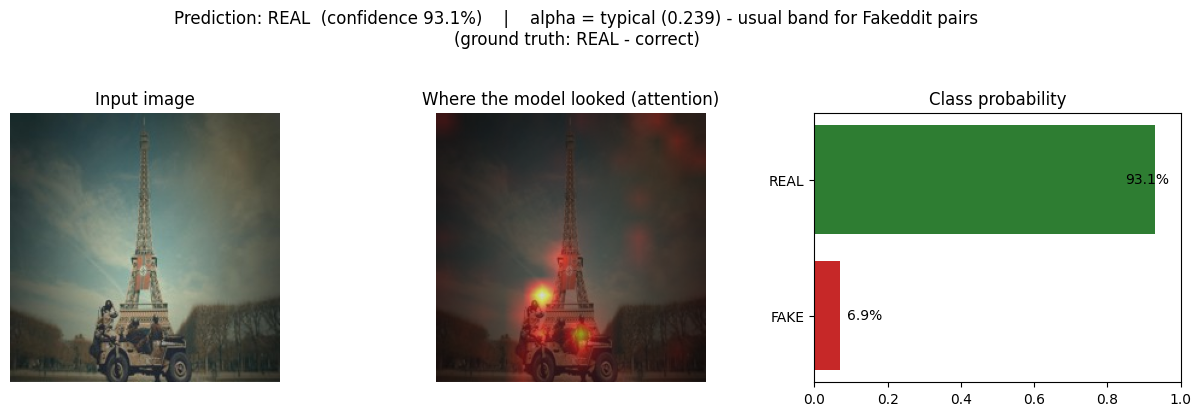

Plain-English read: the strongest REAL-leaning content words are: liberty.
Title: liberty
REAL - wildlife photo, two polar bears on the ice. Clear subject for the attention map.


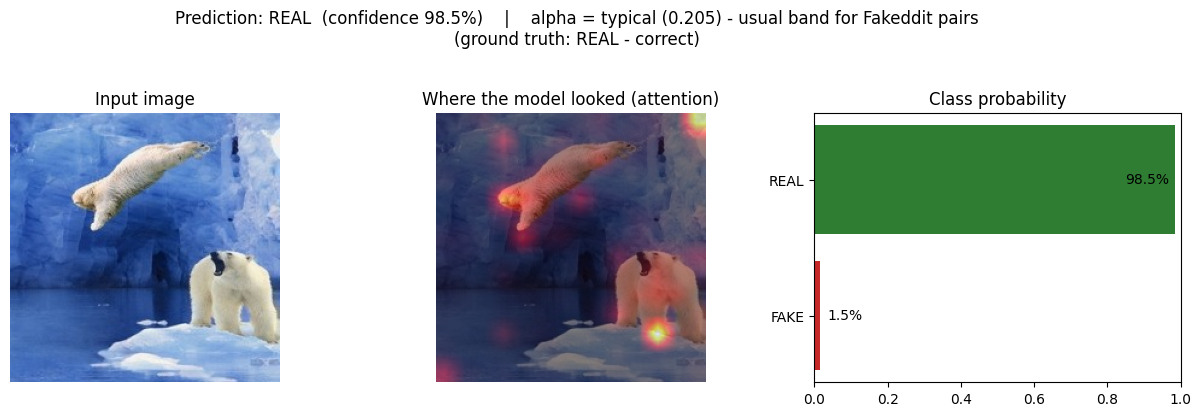

Plain-English read: the strongest REAL-leaning content words are: other.
Title: other discussions
FAKE - title says 'the almost full moon', but the image is a bright lamp atop a flagpole: a false text-image connection - the multimodal cue the model should catch.


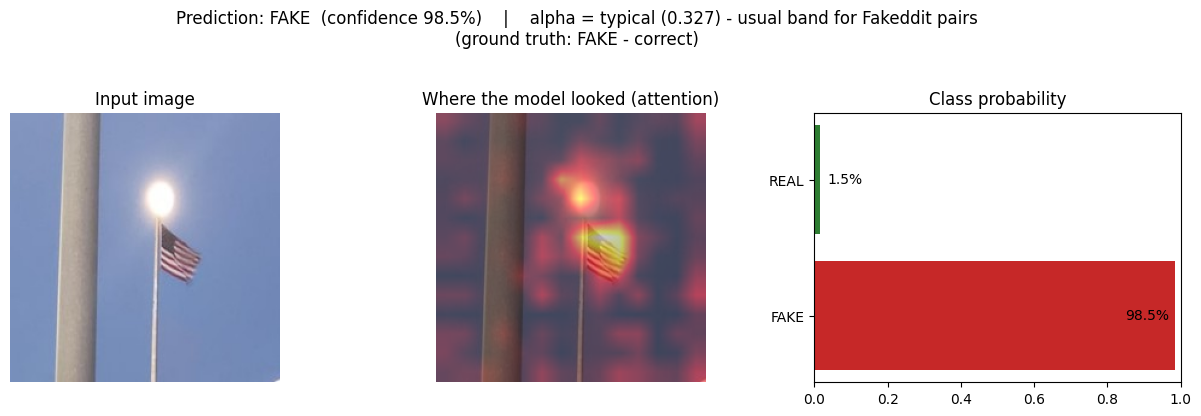

Plain-English read: the strongest FAKE-leaning content words are: flagpole, almost, atop.
Title: the almost full moon atop a flagpole oc
FAKE - a believable graduation photo paired with a fabricated news claim ('student loan debts wiped away'): an image-only check passes, the text gives it away.


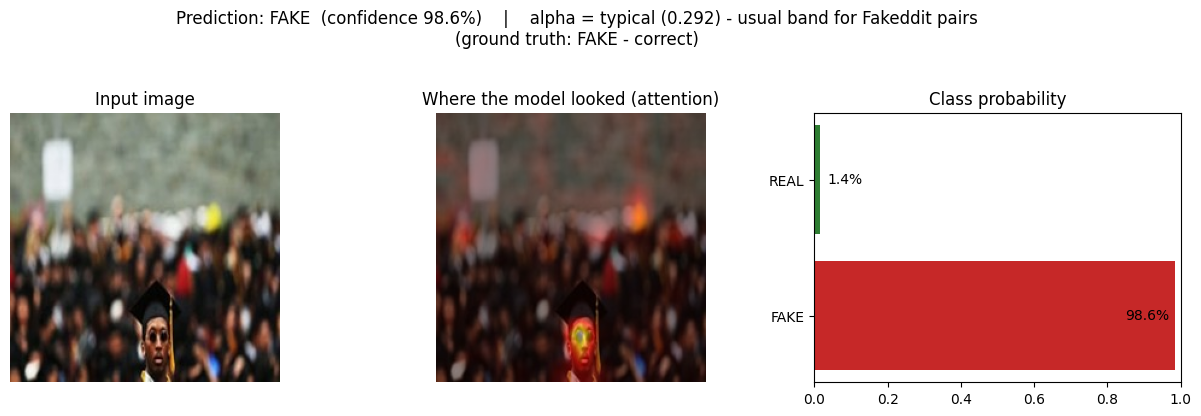

Plain-English read: the strongest FAKE-leaning content words are: missing, student, away.
Title: as paperwork goes missing private student loan debts be wiped away


In [ ]:
# Curated, pre-verified examples - specific Fakeddit test rows this checkpoint
# gets right (vetted with find_correct_samples, below).
CURATED = [
    (15662, "REAL - 'liberty': liberation-of-Paris scene (Eiffel Tower + WWII jeep). Authentic photo."),
    (15368, "REAL - wildlife photo, two polar bears on the ice. Clear subject for the attention map."),
    (16379, "FAKE - title says 'the almost full moon', but the image is a bright lamp atop a flagpole: "
            "a false text-image connection - the multimodal cue the model should catch."),
    (15657, "FAKE - a believable graduation photo paired with a fabricated news claim "
            "('student loan debts wiped away'): an image-only check passes, the text gives it away."),
]

for idx, story in CURATED:
    print('=' * 95)
    print(story)
    show_sample(idx)

## Sanity check — is the demo pipeline correct?

Run the demo on **labelled REAL test samples** (the data notebook 04 scores). If these come out REAL, the pipeline is sound and any FAKE-on-new-inputs behaviour is the model (recall-skew / distribution shift), not a code bug. `live_a` vs `stored_a` also confirms the live alpha matches the precomputed one.

In [ ]:
import h5py, numpy as np

with h5py.File(cfg['data']['hdf5_path'], 'r') as fh:
    splits = fh['splits'][:].astype(str); labels = fh['labels'][:]
    rows = np.where((splits == 'test') & (labels == 0))[0][:6]   # 6 REAL test samples
    print(f"{'row':>6}  {'truth':>5}  {'pred':>5}  {'conf':>5}  {'live_a':>7}  {'stored_a':>8}")
    for row in rows:
        img = Image.fromarray(fh['images'][row].transpose(1, 2, 0).astype('uint8'))
        txt = fh['texts'][row]
        txt = txt.decode() if isinstance(txt, bytes) else str(txt)
        la = compute_alpha(img, txt)
        sa = float(fh['alpha'][row])
        pr, _ = predict(img, txt, la)
        pred = 'FAKE' if pr.argmax() else 'REAL'
        print(f"{row:>6}  {'REAL':>5}  {pred:>5}  {pr.max():>5.2f}  {la:>7.3f}  {sa:>8.3f}")


   row  truth   pred   conf   live_a  stored_a
 14576   REAL   REAL   0.93    0.274     0.274
 14577   REAL   REAL   0.98    0.237     0.237
 14578   REAL   REAL   0.98    0.175     0.175
 14579   REAL   REAL   0.92    0.225     0.225
 14580   REAL   REAL   0.91    0.212     0.212
 14582   REAL   FAKE   0.72    0.210     0.210


## How the examples were vetted

`find_correct_samples()` scans the test set and lists rows the model predicts **correctly and confidently** for both classes - this is how the `CURATED` indices above were chosen. Re-run it to refresh or discover new picks (titles are printed so you can pick presentable ones).

In [ ]:
# Re-run to vet / refresh the CURATED indices above. Printed rows are
# correctly- and confidently-predicted test samples for both classes.
find_correct_samples()

   idx truth  conf  title
 15898  REAL  0.99  a modest proposal
 16889  REAL  0.95  king supreme call me da pizza man
 17018  REAL  0.99  arabiaaaaan niiiiights like arabiaaan daaaays
 15662  REAL  0.93  liberty
 16243  REAL  0.95  photograph of big bill the worlds largest pig
 15368  REAL  0.99  other discussions
 16379  FAKE  0.99  the almost full moon atop a flagpole oc
 16328  FAKE  0.98  this happy running dog
 15657  FAKE  0.99  as paperwork goes missing private student loan debts be wiped away
 15841  FAKE  0.92  first it was college tuition for his employees kids now this ceo will fo
 15053  FAKE  0.89  visited a friend in brussels spotted a picture of xi jinping on the toil
 14644  FAKE  0.94  this cat got a new coat for winter


{0: [(15898, 0.9858561754226685, 'a modest proposal'),
  (16889, 0.9462600946426392, 'king supreme call me da pizza man'),
  (17018, 0.9923535585403442, 'arabiaaaaan niiiiights like arabiaaan daaaays'),
  (15662, 0.9307553172111511, 'liberty'),
  (16243, 0.951251745223999, 'photograph of big bill the worlds largest pig'),
  (15368, 0.9853809475898743, 'other discussions')],
 1: [(16379, 0.9853553771972656, 'the almost full moon atop a flagpole oc'),
  (16328, 0.9771752953529358, 'this happy running dog'),
  (15657,
   0.9857111573219299,
   'as paperwork goes missing private student loan debts be wiped away'),
  (15841,
   0.9226132035255432,
   'first it was college tuition for his employees kids now this ceo will foot the bill for employees weddings'),
  (15053,
   0.8931052684783936,
   'visited a friend in brussels spotted a picture of xi jinping on the toilet in an african bar'),
  (14644, 0.9402996897697449, 'this cat got a new coat for winter')]}

## Known limitation - out-of-distribution inputs

The model is calibrated to the Fakeddit distribution. An **arbitrary web image with an invented title** is out-of-distribution, and the model over-flags **FAKE** with high confidence. We show this **deliberately**: it is a documented property (distribution shift / recall-skew), not a bug - the sanity check above confirms the pipeline is correct on in-distribution data.

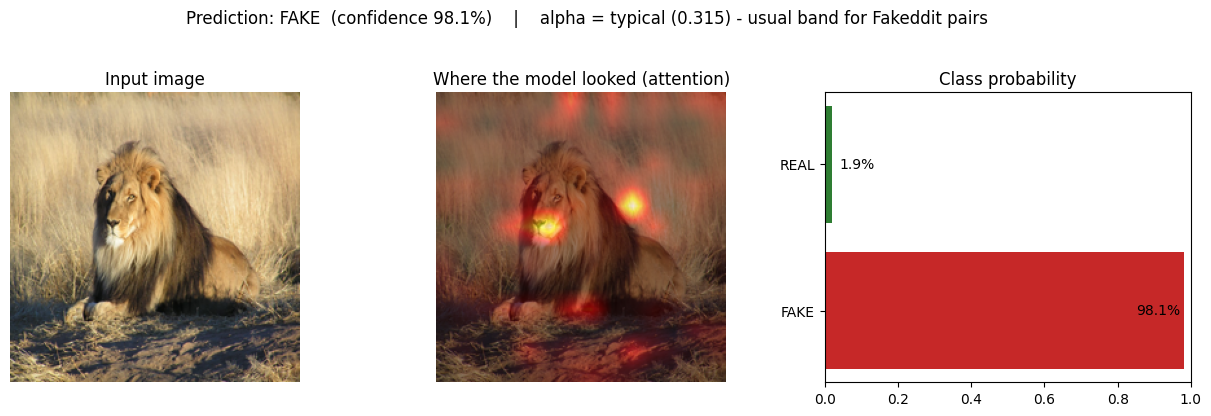

Plain-English read: the strongest FAKE-leaning content words are: savanna, lion, resting.
Title: a lion resting in the savanna


{'pred': 'FAKE',
 'confidence': 0.9807583689689636,
 'alpha': 0.31465601921081543}

In [ ]:
# --- Known limitation: out-of-distribution inputs (shown on purpose) ---
# An arbitrary web image + an invented title is OUTSIDE the Fakeddit distribution
# the model was calibrated on, so it over-flags FAKE with high confidence. This is
# distribution shift / recall-skew - a documented property, NOT a pipeline bug
# (the sanity check above passes on in-distribution data).
demo("a lion resting in the savanna",
     "https://commons.wikimedia.org/wiki/Special:FilePath/Lion_waiting_in_Namibia.jpg")

# Optional safe interactive: keep a REAL test image, swap in your own title.
# Stays in-distribution (real image) while showing text sensitivity. Uncomment:
# demo_custom_title(15368, "two polar bears playing on the ice")